# 📧 Email Marketing Experimentation & Conversion Optimization Analysis

---

> **Client:** E-Commerce Growth Division  
> **Engagement Type:** Marketing Analytics Consulting  
> **Prepared by:** Patience Anono  
> **Dataset Size:** 25,000 customer records | 90-day email campaign   
> **Analysis Date:** January–April 2024
> **Tools:** Python (Pandas, NumPy, SciPy, Matplotlib, Seaborn)
> **Skills Demonstrated:** Funnel Analysis, A/B Testing, Customer Segmentation, Conversion Optimization, Revenue Impact Analysis, Executive Decision Support
---

*This notebook documents a rigorous A/B test evaluation for an e-commerce email marketing campaign.  
The analysis follows a consulting-grade framework: from business context through statistical inference  
to executive recommendations.*


---
## 1. Business Problem

### 1.1 Business Objective

The client, an e-commerce company, seeks to optimize email marketing performance by  
identifying which email variant — A or B — drives superior results across the full  
customer conversion funnel: open → click → purchase → revenue.

The goal is to make a data-driven rollout decision supported by statistical evidence,  
and to quantify the expected revenue uplift from deploying the winning variant at scale.

---

### 1.2 Experiment Objective

Evaluate a controlled A/B test on **25,000 customers** (randomly split into two groups)  
to determine whether **Email Variant B** meaningfully outperforms **Email Variant A**  
on the following KPIs:

| KPI | Description |
|---|---|
| Open Rate | % of recipients who opened the email |
| Click Rate | % of openers who clicked a link |
| Conversion Rate | % of senders who made a purchase |
| Revenue Per Send | Average revenue generated per email sent |
| Unsubscribe Rate | % of recipients who unsubscribed |

---

### 1.3 Success Metrics

The test will be deemed successful if Variant B delivers:
- **Statistically significant improvement** (p < 0.05) in at least 2 of 4 primary KPIs
- **Positive revenue lift** that justifies full rollout
- **No significant increase** in unsubscribe rate

---

### 1.4 Hypotheses

**Null Hypothesis (H₀):**  
> Variant B performs the same as Variant A across all measured KPIs.  
> Any observed difference is due to random chance.

**Alternative Hypothesis (H₁):**  
> Variant B performs significantly better than Variant A on one or more KPIs.  
> The difference is large enough to be practically meaningful.

*Test type: One-tailed (we are testing for improvement, not just difference)*  
*Significance level: α = 0.05*


---
## 📋 Analysis Roadmap

| Phase | Focus |
|-------|-------|
| 1️⃣ Setup & Data Loading | Import libraries, load dataset |
| 2️⃣ Data Cleaning | Fix duplicates, nulls, outliers |
| 3️⃣ Exploratory Data Analysis | Understand the dataset distributions |
| 4️⃣ Funnel Analysis | Open → Click → Purchase rates by variant |
| 5️⃣ Statistical Significance Testing | Prove the results aren't random chance |
| 6️⃣ Segmentation Analysis | Which customers, devices, regions benefit most |
| 7️⃣ Revenue Impact Analysis | Translate statistical results into dollars |
| 8️⃣ Business Recommendations | Clear, data-backed decisions |


---
## 2. Imports & Setup

We configure the environment with all required libraries, a consistent color palette  
aligned to the PA Data Analytics brand and clean display settings.


In [1]:
#Core Libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

#Statistical Testing 
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, norm

#Visualization 
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from matplotlib.ticker import FuncFormatter

#Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)

#Color Palette (PA Data Analytics Brand)
BG_COLOR    = '#282878'   # Indigo – primary background
TEXT_COLOR  = '#9aa0b4'   # Steel – body text
TEAL        = '#2EC4B6'   # Teal – highlights, Variant B
ORANGE      = '#FF9F1C'   # Orange – CTAs, Variant A
WHITE       = '#FFFFFF'
DARK_BG     = '#1a1a4e'   # Deeper indigo for panels
LIGHT_TEXT  = '#e0e3ef'

COLOR_A = ORANGE
COLOR_B = TEAL
PALETTE = [COLOR_A, COLOR_B]

#Plot Theme 
plt.rcParams.update({
    'figure.facecolor':  BG_COLOR,
    'axes.facecolor':    DARK_BG,
    'axes.edgecolor':    TEXT_COLOR,
    'axes.labelcolor':   WHITE,
    'axes.titlecolor':   WHITE,
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'text.color':        WHITE,
    'grid.color':        '#3a3a6e',
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
    'legend.facecolor':  DARK_BG,
    'legend.edgecolor':  TEXT_COLOR,
    'legend.labelcolor': WHITE,
    'font.family':       'DejaVu Sans',
    'figure.titlesize':  16,
    'figure.titleweight': 'bold',
})

#Output Directories
BASE_DIR    = Path('.')
VISUALS_DIR = BASE_DIR / 'visuals'
DATA_DIR    = BASE_DIR / 'data' / 'processed'
VISUALS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, filename):
    path = VISUALS_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    print(f'✅ Saved: {path}')

def pct(val, total):
    return round(100 * val / total, 2) if total > 0 else 0

print('✅ Environment configured successfully.')
print(f'   Visuals → {VISUALS_DIR.resolve()}')
print(f'   Data    → {DATA_DIR.resolve()}')


✅ Environment configured successfully.
   Visuals → C:\Users\Patience\Documents\GITHUB\email-ab-testing-analysis 2\visuals
   Data    → C:\Users\Patience\Documents\GITHUB\email-ab-testing-analysis 2\data\processed


---
## 3. Data Loading & Quality Assessment

### 3.1 Dataset Overview

We load the raw dataset and conduct an initial inventory to understand structure,  
completeness and any data quality concerns before analysis begins.


In [2]:
#Load Dataset 
DATA_PATH = Path('data/raw/Marketing-Experimentation-AB-Testing.csv')
df_raw = pd.read_csv(DATA_PATH)

print('='*60)
print('  EMAIL A/B TEST DATASET — INITIAL OVERVIEW')
print('='*60)
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')
print()
print('Column Names & Data Types')
print(df_raw.dtypes.to_string())
print()
print('First 5 Rows')
df_raw.head()


  EMAIL A/B TEST DATASET — INITIAL OVERVIEW
  Rows    : 25,000
  Columns : 17

Column Names & Data Types
customer_id                   int64
variant                      object
customer_segment             object
age_group                    object
region                       object
device_type                  object
product_category             object
subject_line_type            object
email_send_datetime          object
send_hour                     int64
days_since_last_purchase    float64
opened                        int64
time_to_open_hrs            float64
clicked                       int64
purchased                     int64
revenue_usd                 float64
unsubscribed                  int64

First 5 Rows


,customer_id,variant,customer_segment,age_group,region,device_type,product_category,subject_line_type,email_send_datetime,send_hour,days_since_last_purchase,opened,time_to_open_hrs,clicked,purchased,revenue_usd,unsubscribed
0,10001,A,Returning Customer,45-54,West Africa,Mobile,Food & Beverage,Standard Promo,23/01/2024 17:07,17,104.0000,0,NaN,0,0,0.0000,0
1,10002,A,VIP Customer,35-44,Middle East,Mobile,Electronics,Product Feature,24/03/2024 07:47,7,20.0000,1,8.8700,0,0,0.0000,0
2,10003,B,Loyal Customer,18-24,Europe,Desktop,Sports & Fitness,Urgency + Discount,07/02/2024 11:15,11,14.0000,0,NaN,0,0,0.0000,0
3,10004,B,Returning Customer,18-24,North America,Desktop,Sports & Fitness,Urgency + Discount,13/04/2024 10:08,10,78.0000,1,3.6000,1,0,0.0000,0
4,10005,B,New Customer,18-24,East Africa,Mobile,Home & Living,Social Proof,19/03/2024 18:06,18,NaN,1,6.7300,1,1,136.2600,0


In [3]:
#Statistical Summary 
print('Descriptive Statistics')
df_raw.describe(include='all').T


Descriptive Statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25000.0000,NaN,NaN,NaN,22500.2043,7216.9954,10001.0000,16250.7500,22500.5000,28750.2500,35000.0000
variant,25000,2,A,12639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,25000,5,Returning Customer,8806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,25000,5,25-34,7693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,24875,6,East Africa,8752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,24800,3,Mobile,15403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,25000,6,Fashion & Apparel,6952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject_line_type,25000,6,Standard Promo,5037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_send_datetime,24900,21392,04/04/2024 14:46,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
send_hour,25000.0000,NaN,NaN,NaN,13.9818,4.3268,7.0000,10.0000,14.0000,18.0000,21.0000


### 3.2 Data Quality Checks

In [4]:
# Check for missing values
df_raw.isnull().sum()

customer_id                     0
variant                         0
customer_segment                0
age_group                       0
region                        125
device_type                   200
product_category                0
subject_line_type               0
email_send_datetime           100
send_hour                       0
days_since_last_purchase     7426
opened                          0
time_to_open_hrs            17437
clicked                         0
purchased                       0
revenue_usd                     0
unsubscribed                    0
dtype: int64

In [5]:
# Count total duplicate rows
df_raw.duplicated().sum()

0

In [6]:
# Find duplicates in a specific column
print(df_raw.duplicated(subset=['customer_id']))

0        False
1        False
2        False
3        False
4        False
         ...  
24995    False
24996    False
24997    False
24998    False
24999    False
Length: 25000, dtype: bool


In [7]:
df_raw.duplicated(subset=['customer_id']).sum()

299

In [8]:
#Missing Values
print('='*65)
print('  DATA QUALITY REPORT')
print('='*65)

missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
quality_df  = quality_df[quality_df['Missing Count'] > 0]

if quality_df.empty:
    print('  ✅ No missing values detected.')
else:
    print(f"  {'Column':<30} {'Missing Count':>14} {'Missing %':>10}")
    print('  ' + '-'*56)
    for col, row in quality_df.iterrows():
        print(f"  {col:<30} {int(row['Missing Count']):>14,} {row['Missing %']:>9.2f}%")

print()

#Duplicate & Integrity Checks 
dups    = df_raw.duplicated().sum()
id_dups = df_raw['customer_id'].duplicated().sum()
print(f'  Duplicate rows      : {dups}')
print(f'  Duplicate IDs       : {id_dups}  ⚠️  same ID, different records (data pipeline issue)')
print(f'  Variant values      : {sorted(df_raw["variant"].unique())}')
print(f'  Negative revenue    : {(df_raw["revenue_usd"] < 0).sum()}')
print(f'  Clicked w/o open    : {((df_raw["clicked"]==1) & (df_raw["opened"]==0)).sum()}')
print(f'  Purchased w/o click : {((df_raw["purchased"]==1) & (df_raw["clicked"]==0)).sum()}')

print()
print('Column-Level Notes')

dt_miss  = df_raw['email_send_datetime'].isnull().sum()
dlp_miss = df_raw['days_since_last_purchase'].isnull().sum()
tto_miss = df_raw['time_to_open_hrs'].isnull().sum()
opened_0 = (df_raw['opened'] == 0).sum()

print(f'  email_send_datetime     : {dt_miss:,} missing ({dt_miss/len(df_raw)*100:.2f}%)')
print(f'    → send_hour fully populated; used as primary time feature throughout.')
print(f'  days_since_last_purchase: {dlp_miss:,} missing ({dlp_miss/len(df_raw)*100:.2f}%)')
print(f'    → Structural: new customers with no prior purchase history.')
print(f'      Will impute with median + add boolean flag column.')
print(f'  time_to_open_hrs        : {tto_miss:,} missing ({tto_miss/len(df_raw)*100:.2f}%)')
print(f'    → NOT random. Matches non-openers exactly ({opened_0:,} rows).')
print(f'      Undefined for opened=0. Will fill with -1 sentinel.')

print()
print('Consultant Observation')
print('  No exact duplicate rows — all 25,000 rows are unique send events.')
print('  299 customer_ids appear more than once with differing records;')
print('  each row is a valid send event so all 25,000 rows are retained.')
print('  Issues requiring treatment:')
print('  • region / device_type      — impute with "Unknown"')
print('  • email_send_datetime       — 100 missing; send_hour used as fallback')
print('  • days_since_last_purchase  — 7,426 new customers; impute median + flag')
print('  • time_to_open_hrs          — 17,437 non-openers; structurally N/A → -1')
print('  No negative revenue or funnel logic violations found.')

  DATA QUALITY REPORT
  Column                          Missing Count  Missing %
  --------------------------------------------------------
  region                                    125      0.50%
  device_type                               200      0.80%
  email_send_datetime                       100      0.40%
  days_since_last_purchase                7,426     29.70%
  time_to_open_hrs                       17,437     69.75%

  Duplicate rows      : 0
  Duplicate IDs       : 299  ⚠️  same ID, different records (data pipeline issue)
  Variant values      : ['A', 'B']
  Negative revenue    : 0
  Clicked w/o open    : 0
  Purchased w/o click : 0

Column-Level Notes
  email_send_datetime     : 100 missing (0.40%)
    → send_hour fully populated; used as primary time feature throughout.
  days_since_last_purchase: 7,426 missing (29.70%)
    → Structural: new customers with no prior purchase history.
      Will impute with median + add boolean flag column.
  time_to_open_hrs        : 1

In [9]:
#Clean Dataset 
df = df_raw.copy()

# 1. Categorical missingness
for col in ['region', 'device_type']:
    df[col] = df[col].fillna('Unknown')
print(f'  ✅ region / device_type    : missing filled with "Unknown"')

# 2. email_send_datetime — parse only, NaTs stay (send_hour is primary)
df['email_send_datetime'] = pd.to_datetime(df['email_send_datetime'], errors='coerce')
print(f'  ✅ email_send_datetime     : parsed to datetime ({df["email_send_datetime"].isnull().sum()} NaTs remain — using send_hour)')

# 3. days_since_last_purchase — impute median + flag new customers
dlp_median = df['days_since_last_purchase'].median()
df['new_customer_flag']         = df['days_since_last_purchase'].isnull().astype(int)
df['days_since_last_purchase']  = df['days_since_last_purchase'].fillna(dlp_median)
print(f'  ✅ days_since_last_purchase: {df["new_customer_flag"].sum():,} new-customer rows flagged; imputed with median ({dlp_median:.0f} days)')

# 4. time_to_open_hrs — fill non-openers with -1 sentinel
df['time_to_open_hrs'] = df['time_to_open_hrs'].fillna(-1)
print(f'  ✅ time_to_open_hrs        : non-openers filled with -1 (use opened==1 filter for open-time analysis)')

# 5. send_time_bucket from send_hour
def hour_to_bucket(h):
    if   5 <= h < 12: return 'Morning'
    elif 12 <= h < 17: return 'Afternoon'
    elif 17 <= h < 21: return 'Evening'
    else:              return 'Night'

df['send_time_bucket'] = df['send_hour'].apply(hour_to_bucket)
print(f'  ✅ send_time_bucket        : derived from send_hour')

# ── Final check ───────────────────────────────────────────────────────────────
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print()
print(f'✅ Clean dataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns')
if remaining_nulls.empty:
    print('   No unexpected nulls remaining.')
else:
    print('   Remaining nulls (expected):')
    for col, val in remaining_nulls.items():
        print(f'   {col}: {val}')

  ✅ region / device_type    : missing filled with "Unknown"
  ✅ email_send_datetime     : parsed to datetime (100 NaTs remain — using send_hour)
  ✅ days_since_last_purchase: 7,426 new-customer rows flagged; imputed with median (60 days)
  ✅ time_to_open_hrs        : non-openers filled with -1 (use opened==1 filter for open-time analysis)
  ✅ send_time_bucket        : derived from send_hour

✅ Clean dataset ready: 25,000 rows × 19 columns
   Remaining nulls (expected):
   email_send_datetime: 100


---
## 4. Exploratory Data Analysis

Before statistical testing, we examine data distributions to confirm balance  
across groups and identify patterns that will inform segmentation analysis.


### 4.1 Variant Split

✅ Saved: visuals\3_1_variant_split.png


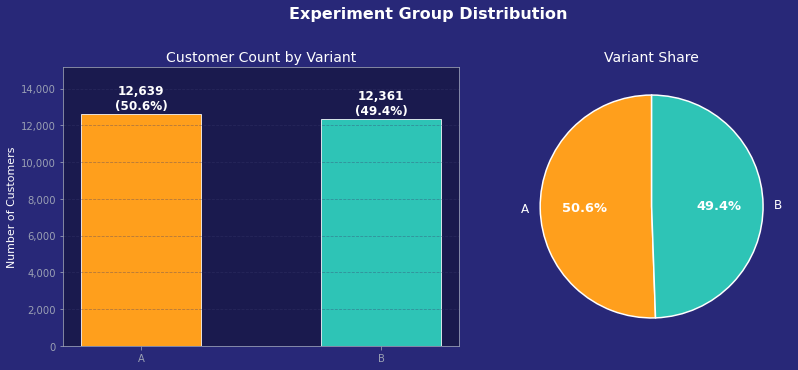


Variant A: 12,639 customers (50.6%)
Variant B: 12,361 customers (49.4%)

📌 Insight: Groups are well-balanced (~50/50), confirming proper randomization.


In [10]:
#3_1 Variant Split
variant_counts = df['variant'].value_counts()
variant_pct    = df['variant'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Experiment Group Distribution', fontsize=16, fontweight='bold', color=WHITE, y=1.02)

# Bar chart
bars = axes[0].bar(variant_counts.index, variant_counts.values, color=PALETTE, width=0.5, edgecolor=WHITE, linewidth=0.8)
for bar, cnt, pct_val in zip(bars, variant_counts.values, variant_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{cnt:,}\n({pct_val:.1f}%)', ha='center', va='bottom', color=WHITE, fontsize=12, fontweight='bold')
axes[0].set_title('Customer Count by Variant', color=WHITE)
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, variant_counts.max() * 1.2)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    variant_counts.values, labels=variant_counts.index,
    colors=PALETTE, autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor=WHITE, linewidth=1.5),
    textprops={'color': WHITE, 'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('Variant Share', color=WHITE)

plt.tight_layout()
save_fig(fig, '3_1_variant_split.png')
plt.show()

print(f'\nVariant A: {variant_counts["A"]:,} customers ({variant_pct["A"]:.1f}%)')
print(f'Variant B: {variant_counts["B"]:,} customers ({variant_pct["B"]:.1f}%)')
print('\n📌 Insight: Groups are well-balanced (~50/50), confirming proper randomization.')


### 4.2 Segment Balance

✅ Saved: visuals\3_2_segment_balance.png


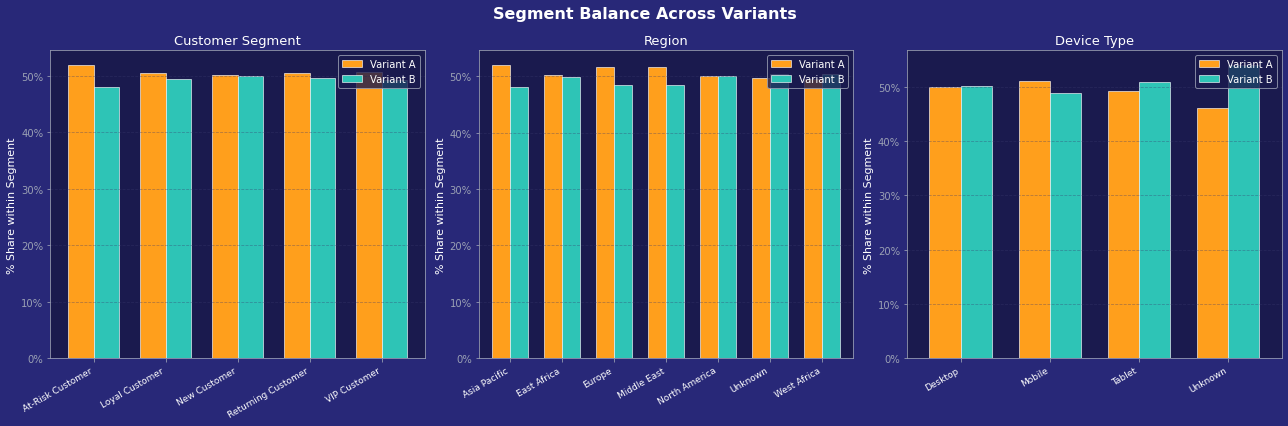

📌 Insight: Variant distribution is balanced across all key segments, validating test integrity.


In [11]:
#3_2 Segment Balance 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segment Balance Across Variants', fontsize=16, fontweight='bold', color=WHITE)

segment_cols = ['customer_segment', 'region', 'device_type']
titles       = ['Customer Segment', 'Region', 'Device Type']

for ax, col, title in zip(axes, segment_cols, titles):
    ct = df.groupby([col, 'variant']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=PALETTE, edgecolor=WHITE, linewidth=0.6, width=0.7)
    ax.set_title(title, color=WHITE, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('% Share within Segment')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', color=WHITE, fontsize=9)
    ax.legend(['Variant A', 'Variant B'], loc='upper right')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.grid(axis='y')

plt.tight_layout()
save_fig(fig, '3_2_segment_balance.png')
plt.show()
print('📌 Insight: Variant distribution is balanced across all key segments, validating test integrity.')


### 4.3 Demographic Overview

✅ Saved: visuals\3_3_demographics.png


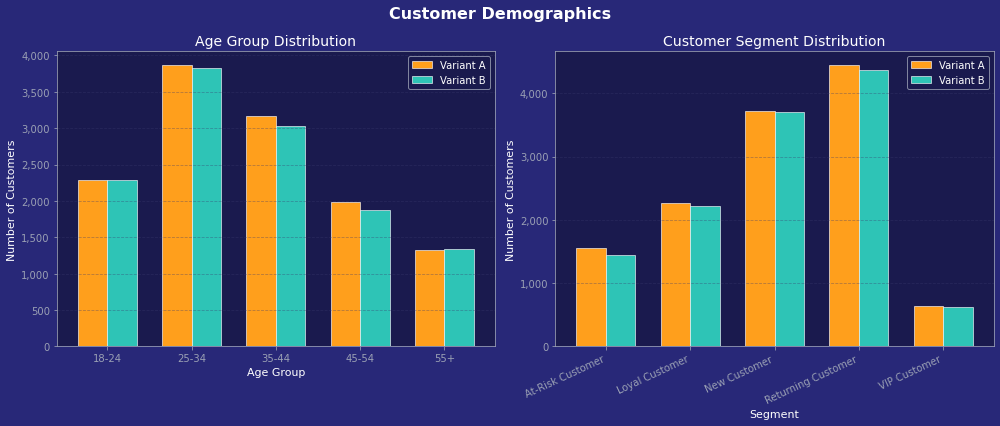

📌 Insight: Demographic makeup is consistent across variants, ruling out age or segment skew.


In [12]:
#3_3 Demographics 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Demographics', fontsize=16, fontweight='bold', color=WHITE)

# Age Group
age_ct = df.groupby(['age_group', 'variant']).size().unstack(fill_value=0)
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_ct = age_ct.reindex([a for a in age_order if a in age_ct.index])
age_ct.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor=WHITE, linewidth=0.6, width=0.7)
axes[0].set_title('Age Group Distribution', color=WHITE)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['Variant A', 'Variant B'])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y')

# Gender fallback → customer_segment distribution if no gender
if 'gender' in df.columns and df['gender'].nunique() > 1:
    gender_ct = df.groupby(['gender', 'variant']).size().unstack(fill_value=0)
    gender_ct.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor=WHITE, linewidth=0.6, width=0.5)
    axes[1].set_title('Gender Distribution', color=WHITE)
    axes[1].set_xlabel('Gender')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
else:
    seg_ct = df.groupby(['customer_segment', 'variant']).size().unstack(fill_value=0)
    seg_ct.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor=WHITE, linewidth=0.6, width=0.7)
    axes[1].set_title('Customer Segment Distribution', color=WHITE)
    axes[1].set_xlabel('Segment')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')

axes[1].set_ylabel('Number of Customers')
axes[1].legend(['Variant A', 'Variant B'])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='y')

plt.tight_layout()
save_fig(fig, '3_3_demographics.png')
plt.show()
print('📌 Insight: Demographic makeup is consistent across variants, ruling out age or segment skew.')


### 4.4 Revenue Distribution

✅ Saved: visuals\3_4_revenue_distribution.png


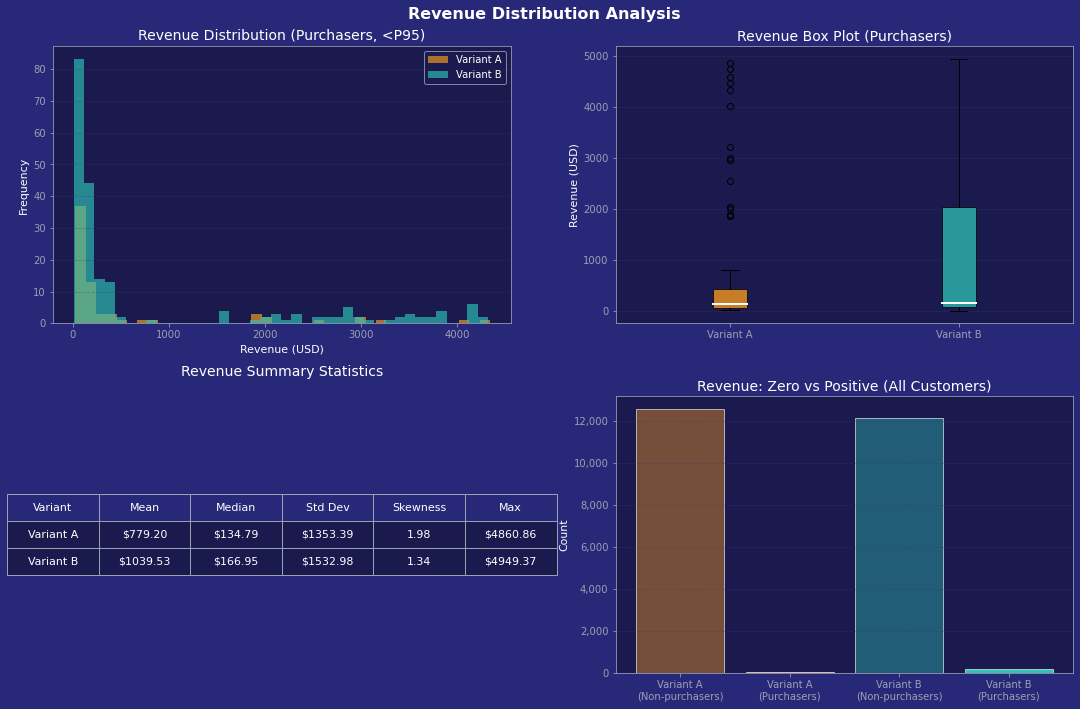

📌 Insight: Revenue is highly right-skewed — most customers generate $0, with a small tail of
   high-value transactions. This mandates non-parametric testing for revenue significance.


In [13]:
#3_4 Revenue Distribution
purchasers = df[df['purchased'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Revenue Distribution Analysis', fontsize=16, fontweight='bold', color=WHITE)

# Histogram by variant (purchasers only)
for variant, color, label in [('A', COLOR_A, 'Variant A'), ('B', COLOR_B, 'Variant B')]:
    data = purchasers[purchasers['variant'] == variant]['revenue_usd']
    axes[0,0].hist(data[data < data.quantile(0.95)], bins=40, color=color, alpha=0.65, label=label, edgecolor='none')
axes[0,0].set_title('Revenue Distribution (Purchasers, <P95)', color=WHITE)
axes[0,0].set_xlabel('Revenue (USD)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(axis='y')

# Box plot by variant
bp_data = [purchasers[purchasers['variant'] == v]['revenue_usd'].values for v in ['A', 'B']]
bp = axes[0,1].boxplot(bp_data, labels=['Variant A', 'Variant B'],
                        patch_artist=True, medianprops=dict(color=WHITE, linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0,1].set_title('Revenue Box Plot (Purchasers)', color=WHITE)
axes[0,1].set_ylabel('Revenue (USD)')
axes[0,1].grid(axis='y')

# Summary stats table
stats_data = []
for variant in ['A', 'B']:
    rev = purchasers[purchasers['variant'] == variant]['revenue_usd']
    stats_data.append({
        'Variant': f'Variant {variant}',
        'Mean': f'${rev.mean():.2f}',
        'Median': f'${rev.median():.2f}',
        'Std Dev': f'${rev.std():.2f}',
        'Skewness': f'{rev.skew():.2f}',
        'Max': f'${rev.max():.2f}'
    })
stats_tbl = pd.DataFrame(stats_data)

axes[1,0].axis('off')
tbl = axes[1,0].table(
    cellText=stats_tbl.values, colLabels=stats_tbl.columns,
    cellLoc='center', loc='center',
    cellColours=[[DARK_BG]*len(stats_tbl.columns)]*len(stats_tbl),
    colColours=[BG_COLOR]*len(stats_tbl.columns)
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_text_props(color=WHITE)
    cell.set_edgecolor(TEXT_COLOR)
axes[1,0].set_title('Revenue Summary Statistics', color=WHITE, pad=20)

# All customers — revenue = 0 vs > 0
for variant, color in [('A', COLOR_A), ('B', COLOR_B)]:
    rev_all = df[df['variant'] == variant]['revenue_usd']
    axes[1,1].bar(['Variant ' + variant + '\n(Non-purchasers)',
                    'Variant ' + variant + '\n(Purchasers)'],
                   [(rev_all == 0).sum(), (rev_all > 0).sum()],
                   color=[color + '66', color], edgecolor=WHITE, linewidth=0.6)
axes[1,1].set_title('Revenue: Zero vs Positive (All Customers)', color=WHITE)
axes[1,1].set_ylabel('Count')
axes[1,1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1,1].grid(axis='y')

plt.tight_layout()
save_fig(fig, '3_4_revenue_distribution.png')
plt.show()
print('📌 Insight: Revenue is highly right-skewed — most customers generate $0, with a small tail of')
print('   high-value transactions. This mandates non-parametric testing for revenue significance.')


---
## 5. Funnel Analysis

We construct the full marketing funnel (Sent → Opened → Clicked → Purchased)  
for each variant and quantify the lift at every stage.


In [14]:
#Funnel Metrics
funnel = {}
for v in ['A', 'B']:
    grp = df[df['variant'] == v]
    n   = len(grp)
    funnel[v] = {
        'Sent'      : n,
        'Opened'    : grp['opened'].sum(),
        'Clicked'   : grp['clicked'].sum(),
        'Purchased' : grp['purchased'].sum(),
        'Revenue'   : grp['revenue_usd'].sum(),
    }

fdf = pd.DataFrame(funnel).T
fdf['Open Rate %']       = (fdf['Opened']    / fdf['Sent'])      * 100
fdf['Click Rate %']      = (fdf['Clicked']   / fdf['Sent'])      * 100
fdf['Conversion Rate %'] = (fdf['Purchased'] / fdf['Sent'])      * 100
fdf['Revenue Per Send']  =  fdf['Revenue']   / fdf['Sent']

print('='*65)
print('  FUNNEL METRICS BY VARIANT')
print('='*65)
print(fdf[['Sent','Opened','Clicked','Purchased','Open Rate %',
           'Click Rate %','Conversion Rate %','Revenue Per Send']].to_string())


  FUNNEL METRICS BY VARIANT
        Sent    Opened   Clicked  Purchased  Open Rate %  Click Rate %  Conversion Rate %  Revenue Per Send
A 12639.0000 3032.0000  536.0000    74.0000      23.9892        4.2408             0.5855            4.5622
B 12361.0000 4531.0000 1255.0000   218.0000      36.6556       10.1529             1.7636           18.3333


### 5.1 Funnel Comparison Chart

✅ Saved: visuals\4_1_funnel_analysis.png


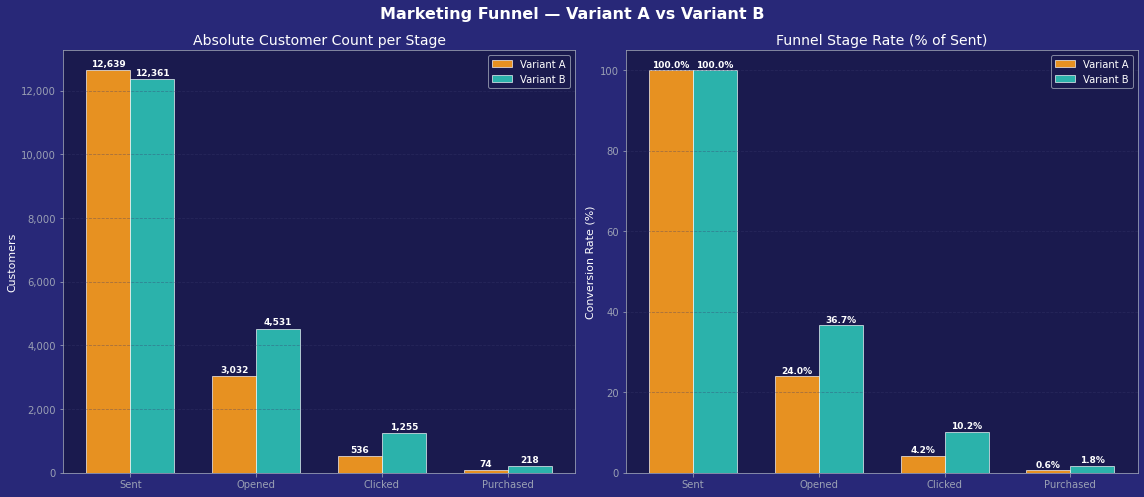

In [15]:
#4_1 Funnel Analysis 
stages  = ['Sent', 'Opened', 'Clicked', 'Purchased']
vals_A  = [funnel['A'][s] for s in stages]
vals_B  = [funnel['B'][s] for s in stages]
pcts_A  = [100 * funnel['A'][s] / funnel['A']['Sent'] for s in stages]
pcts_B  = [100 * funnel['B'][s] / funnel['B']['Sent'] for s in stages]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Marketing Funnel — Variant A vs Variant B', fontsize=16, fontweight='bold', color=WHITE)

x    = np.arange(len(stages))
w    = 0.35

# Bar chart
bars_a = axes[0].bar(x - w/2, vals_A, w, label='Variant A', color=COLOR_A, edgecolor=WHITE, linewidth=0.7, alpha=0.9)
bars_b = axes[0].bar(x + w/2, vals_B, w, label='Variant B', color=COLOR_B, edgecolor=WHITE, linewidth=0.7, alpha=0.9)
for bar, val in zip(bars_a, vals_A):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
for bar, val in zip(bars_b, vals_B):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
axes[0].set_title('Absolute Customer Count per Stage')
axes[0].set_xticks(x)
axes[0].set_xticklabels(stages)
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()
axes[0].grid(axis='y')

# Conversion % chart
bars_pa = axes[1].bar(x - w/2, pcts_A, w, label='Variant A', color=COLOR_A, edgecolor=WHITE, linewidth=0.7, alpha=0.9)
bars_pb = axes[1].bar(x + w/2, pcts_B, w, label='Variant B', color=COLOR_B, edgecolor=WHITE, linewidth=0.7, alpha=0.9)
for bar, pval in zip(bars_pa, pcts_A):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pval:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
for bar, pval in zip(bars_pb, pcts_B):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pval:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
axes[1].set_title('Funnel Stage Rate (% of Sent)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(stages)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
save_fig(fig, '4_1_funnel_analysis.png')
plt.show()


### 5.2 Funnel Lift Analysis

  FUNNEL LIFT ANALYSIS
  Metric                  Variant A  Variant B   Abs Lift   Rel Lift
  ----------------------------------------------------------
  Open Rate                  23.99%     36.66%    +12.67%    +52.80%
  Click Rate                  4.24%     10.15%     +5.91%   +139.41%
  Conversion Rate             0.59%      1.76%     +1.18%   +201.22%
  Revenue Per Send       $  4.5622 $ 18.3333 $+13.7711   +301.86%
✅ Saved: visuals\4_2_funnel_rates.png


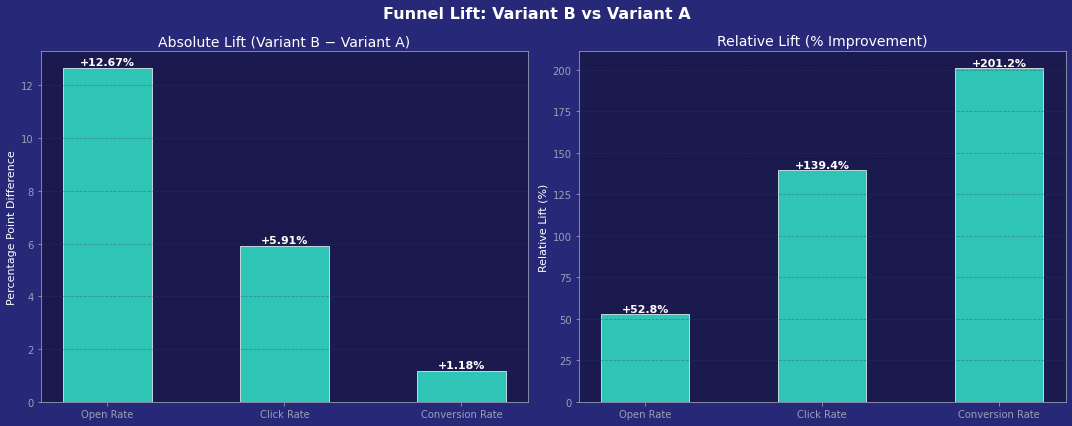

In [16]:
#4_2 Funnel Rates & Lift 
metrics = ['Open Rate %', 'Click Rate %', 'Conversion Rate %']
labels  = ['Open Rate', 'Click Rate', 'Conversion Rate']

abs_lift = [fdf.loc['B', m] - fdf.loc['A', m] for m in metrics]
rel_lift = [(fdf.loc['B', m] - fdf.loc['A', m]) / fdf.loc['A', m] * 100 for m in metrics]

rev_abs_lift = fdf.loc['B', 'Revenue Per Send'] - fdf.loc['A', 'Revenue Per Send']
rev_rel_lift = rev_abs_lift / fdf.loc['A', 'Revenue Per Send'] * 100

print('='*60)
print('  FUNNEL LIFT ANALYSIS')
print('='*60)
print(f'  {"Metric":<22} {"Variant A":>10} {"Variant B":>10} {"Abs Lift":>10} {"Rel Lift":>10}')
print('  ' + '-'*58)
for lbl, m, al, rl in zip(labels, metrics, abs_lift, rel_lift):
    print(f'  {lbl:<22} {fdf.loc["A",m]:>9.2f}% {fdf.loc["B",m]:>9.2f}% {al:>+9.2f}% {rl:>+9.2f}%')
print(f'  {"Revenue Per Send":<22} ${fdf.loc["A","Revenue Per Send"]:>8.4f} ${fdf.loc["B","Revenue Per Send"]:>8.4f} ${rev_abs_lift:>+8.4f} {rev_rel_lift:>+9.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Funnel Lift: Variant B vs Variant A', fontsize=16, fontweight='bold', color=WHITE)

# Absolute lift bars
bar_colors = [TEAL if x >= 0 else ORANGE for x in abs_lift]
bars = axes[0].bar(labels, abs_lift, color=bar_colors, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars, abs_lift):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.02 if val >= 0 else -0.08),
                 f'{val:+.2f}%', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
axes[0].axhline(0, color=WHITE, linewidth=0.8, linestyle='--')
axes[0].set_title('Absolute Lift (Variant B − Variant A)')
axes[0].set_ylabel('Percentage Point Difference')
axes[0].grid(axis='y')

# Relative lift
bar_colors2 = [TEAL if x >= 0 else ORANGE for x in rel_lift]
bars2 = axes[1].bar(labels, rel_lift, color=bar_colors2, edgecolor=WHITE, linewidth=0.7, width=0.5)
for bar, val in zip(bars2, rel_lift):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.2 if val >= 0 else -1.0),
                 f'{val:+.1f}%', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
axes[1].axhline(0, color=WHITE, linewidth=0.8, linestyle='--')
axes[1].set_title('Relative Lift (% Improvement)')
axes[1].set_ylabel('Relative Lift (%)')
axes[1].grid(axis='y')

plt.tight_layout()
save_fig(fig, '4_2_funnel_rates.png')
plt.show()


### 5.3 Funnel Waterfall Chart

✅ Saved: visuals\4_3_funnel_waterfall.png


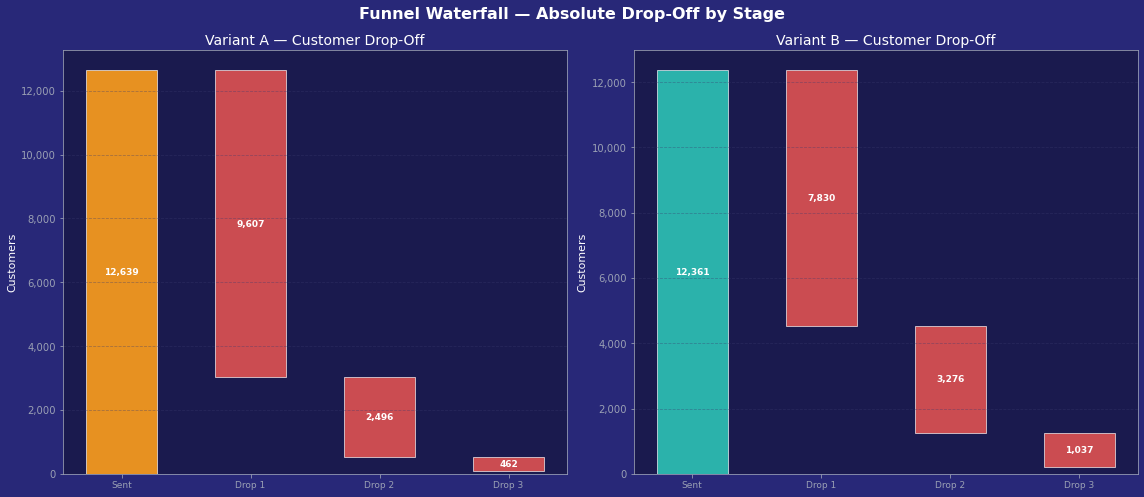

📌 Insight: The largest drop-off for both variants occurs at the Open→Click stage,
   suggesting subject line and preview text optimization will yield the highest ROI.


In [17]:
#4_3 Funnel Waterfall 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Funnel Waterfall — Absolute Drop-Off by Stage', fontsize=16, fontweight='bold', color=WHITE)

for ax, variant, color, label in [(axes[0], 'A', COLOR_A, 'Variant A'), (axes[1], 'B', COLOR_B, 'Variant B')]:
    stages_wf = ['Sent', 'Opened', 'Clicked', 'Purchased']
    vals_wf   = [funnel[variant][s] for s in stages_wf]
    drops     = [vals_wf[i] - vals_wf[i+1] for i in range(len(vals_wf)-1)]
    
    bar_vals   = [vals_wf[0]] + drops
    bar_labels = ['Sent'] + ['Drop ' + str(j+1) for j in range(len(drops))]
    bar_colors_wf = [color] + ['#e05252'] * len(drops)
    
    bottoms = [0]
    running = vals_wf[0]
    for d in drops:
        bottoms.append(running - d)
        running -= d
    
    bars_wf = ax.bar(bar_labels, bar_vals, color=bar_colors_wf, edgecolor=WHITE, linewidth=0.7,
                     bottom=[0] + bottoms[1:], width=0.55, alpha=0.9)
    
    for bar, val, bot in zip(bars_wf, bar_vals, [0] + bottoms[1:]):
        ax.text(bar.get_x() + bar.get_width()/2, bot + val/2,
                f'{val:,}', ha='center', va='center', color=WHITE, fontsize=9, fontweight='bold')
    
    ax.set_title(f'{label} — Customer Drop-Off', color=WHITE)
    ax.set_ylabel('Customers')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xticklabels(bar_labels, fontsize=9)
    ax.grid(axis='y')

plt.tight_layout()
save_fig(fig, '4_3_funnel_waterfall.png')
plt.show()
print('📌 Insight: The largest drop-off for both variants occurs at the Open→Click stage,')
print('   suggesting subject line and preview text optimization will yield the highest ROI.')


---
## 6. Statistical Testing

We apply rigorous hypothesis tests appropriate for each metric type.  
Binary metrics (open, click, purchase) use the **Two-Proportion Z-Test**.  
Continuous revenue uses both the **Mann-Whitney U Test** (non-parametric) and **Independent T-Test**.


In [18]:
#Helper: Two-Proportion Z-Test 
def two_prop_z_test(n1, x1, n2, x2, alternative='larger'):
    """
    n1, n2: group sizes
    x1, x2: successes
    alternative: 'larger' (one-tailed, B > A)
    """
    p1 = x1 / n1
    p2 = x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z  = (p2 - p1) / se   # B vs A
    if alternative == 'larger':
        p_val = 1 - norm.cdf(z)
    elif alternative == 'two-sided':
        p_val = 2 * (1 - norm.cdf(abs(z)))
    else:
        p_val = norm.cdf(z)
    ci_lower = (p2 - p1) - 1.96 * se
    ci_upper = (p2 - p1) + 1.96 * se
    return z, p_val, ci_lower, ci_upper

n_A = funnel['A']['Sent']
n_B = funnel['B']['Sent']

print('='*65)
print('  STATISTICAL SIGNIFICANCE TESTING — α = 0.05')
print('  Hypothesis: Variant B > Variant A (one-tailed)')
print('='*65)


  STATISTICAL SIGNIFICANCE TESTING — α = 0.05
  Hypothesis: Variant B > Variant A (one-tailed)


In [19]:
#6.1 Open Rate Z-Test 
x_A = funnel['A']['Opened']
x_B = funnel['B']['Opened']
z_open, p_open, ci_lo_open, ci_hi_open = two_prop_z_test(n_A, x_A, n_B, x_B)

print('\n── Open Rate Test ─────────────────────────────────────────')
print(f'  Variant A Open Rate : {x_A/n_A*100:.3f}%  ({x_A:,}/{n_A:,})')
print(f'  Variant B Open Rate : {x_B/n_B*100:.3f}%  ({x_B:,}/{n_B:,})')
print(f'  Z-Statistic         : {z_open:.4f}')
print(f'  P-Value             : {p_open:.4f}')
print(f'  95% CI on Lift      : [{ci_lo_open*100:.3f}%, {ci_hi_open*100:.3f}%]')
print(f'  Confidence Level    : {(1-p_open)*100:.1f}%')
sig = '✅ SIGNIFICANT' if p_open < 0.05 else '❌ NOT SIGNIFICANT'
print(f'  Result              : {sig}')



── Open Rate Test ─────────────────────────────────────────
  Variant A Open Rate : 23.989%  (3,032/12,639)
  Variant B Open Rate : 36.656%  (4,531/12,361)
  Z-Statistic         : 21.7983
  P-Value             : 0.0000
  95% CI on Lift      : [11.527%, 13.805%]
  Confidence Level    : 100.0%
  Result              : ✅ SIGNIFICANT


In [20]:
#6.2 Click Rate Z-Test
x_A = funnel['A']['Clicked']
x_B = funnel['B']['Clicked']
z_click, p_click, ci_lo_click, ci_hi_click = two_prop_z_test(n_A, x_A, n_B, x_B)

print('\n── Click Rate Test ────────────────────────────────────────')
print(f'  Variant A Click Rate : {x_A/n_A*100:.3f}%  ({x_A:,}/{n_A:,})')
print(f'  Variant B Click Rate : {x_B/n_B*100:.3f}%  ({x_B:,}/{n_B:,})')
print(f'  Z-Statistic          : {z_click:.4f}')
print(f'  P-Value              : {p_click:.4f}')
print(f'  95% CI on Lift       : [{ci_lo_click*100:.3f}%, {ci_hi_click*100:.3f}%]')
print(f'  Confidence Level     : {(1-p_click)*100:.1f}%')
sig = '✅ SIGNIFICANT' if p_click < 0.05 else '❌ NOT SIGNIFICANT'
print(f'  Result               : {sig}')



── Click Rate Test ────────────────────────────────────────
  Variant A Click Rate : 4.241%  (536/12,639)
  Variant B Click Rate : 10.153%  (1,255/12,361)
  Z-Statistic          : 18.1224
  P-Value              : 0.0000
  95% CI on Lift       : [5.273%, 6.551%]
  Confidence Level     : 100.0%
  Result               : ✅ SIGNIFICANT


In [21]:
#6.3 Conversion Rate Z-Test
x_A = funnel['A']['Purchased']
x_B = funnel['B']['Purchased']
z_conv, p_conv, ci_lo_conv, ci_hi_conv = two_prop_z_test(n_A, x_A, n_B, x_B)

print('\n── Conversion Rate Test ───────────────────────────────────')
print(f'  Variant A Conv Rate : {x_A/n_A*100:.3f}%  ({x_A:,}/{n_A:,})')
print(f'  Variant B Conv Rate : {x_B/n_B*100:.3f}%  ({x_B:,}/{n_B:,})')
print(f'  Z-Statistic         : {z_conv:.4f}')
print(f'  P-Value             : {p_conv:.4f}')
print(f'  95% CI on Lift      : [{ci_lo_conv*100:.3f}%, {ci_hi_conv*100:.3f}%]')
print(f'  Confidence Level    : {(1-p_conv)*100:.1f}%')
sig = '✅ SIGNIFICANT' if p_conv < 0.05 else '❌ NOT SIGNIFICANT'
print(f'  Result              : {sig}')



── Conversion Rate Test ───────────────────────────────────
  Variant A Conv Rate : 0.585%  (74/12,639)
  Variant B Conv Rate : 1.764%  (218/12,361)
  Z-Statistic         : 8.6683
  P-Value             : 0.0000
  95% CI on Lift      : [0.912%, 1.445%]
  Confidence Level    : 100.0%
  Result              : ✅ SIGNIFICANT


In [22]:
# ── 6.4 Revenue Test (Mann-Whitney U + T-Test) ───────────────────────────────
rev_A = df[df['variant'] == 'A']['revenue_usd'].values
rev_B = df[df['variant'] == 'B']['revenue_usd'].values

u_stat, p_mw = mannwhitneyu(rev_B, rev_A, alternative='greater')
t_stat, p_tt = ttest_ind(rev_B, rev_A, alternative='greater', equal_var=False)

print('\n── Revenue Test ───────────────────────────────────────────')
print(f'  Variant A Mean Revenue : ${np.mean(rev_A):.4f}')
print(f'  Variant B Mean Revenue : ${np.mean(rev_B):.4f}')
print()
print(f'  Mann-Whitney U Stat    : {u_stat:.0f}')
print(f'  Mann-Whitney P-Value   : {p_mw:.4f}')
sig_mw = '✅ SIGNIFICANT' if p_mw < 0.05 else '❌ NOT SIGNIFICANT'
print(f'  Mann-Whitney Result    : {sig_mw}')
print()
print(f'  Welch T-Statistic      : {t_stat:.4f}')
print(f'  Welch T P-Value        : {p_tt:.4f}')
sig_tt = '✅ SIGNIFICANT' if p_tt < 0.05 else '❌ NOT SIGNIFICANT'
print(f'  Welch T Result         : {sig_tt}')
print()
print('  📌 Mann-Whitney is preferred due to non-normal, zero-heavy revenue distribution.')



── Revenue Test ───────────────────────────────────────────
  Variant A Mean Revenue : $4.5622
  Variant B Mean Revenue : $18.3333

  Mann-Whitney U Stat    : 79036470
  Mann-Whitney P-Value   : 0.0000
  Mann-Whitney Result    : ✅ SIGNIFICANT

  Welch T-Statistic      : 5.6365
  Welch T P-Value        : 0.0000
  Welch T Result         : ✅ SIGNIFICANT

  📌 Mann-Whitney is preferred due to non-normal, zero-heavy revenue distribution.


### 6.5 Significance Summary

✅ Saved: visuals\5_4_significance_summary.png


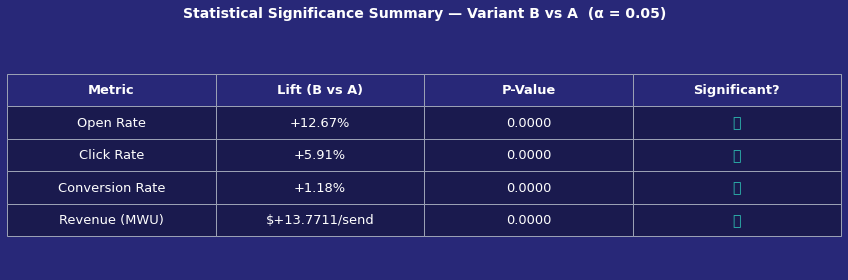

In [23]:
#5_4 Significance Summary
results = [
    ['Open Rate',       f'{fdf.loc["B","Open Rate %"]-fdf.loc["A","Open Rate %"]:+.2f}%',    f'{p_open:.4f}',  '✅' if p_open < 0.05 else '❌'],
    ['Click Rate',      f'{fdf.loc["B","Click Rate %"]-fdf.loc["A","Click Rate %"]:+.2f}%',  f'{p_click:.4f}', '✅' if p_click < 0.05 else '❌'],
    ['Conversion Rate', f'{fdf.loc["B","Conversion Rate %"]-fdf.loc["A","Conversion Rate %"]:+.2f}%', f'{p_conv:.4f}', '✅' if p_conv < 0.05 else '❌'],
    ['Revenue (MWU)',   f'${fdf.loc["B","Revenue Per Send"]-fdf.loc["A","Revenue Per Send"]:+.4f}/send', f'{p_mw:.4f}', '✅' if p_mw < 0.05 else '❌'],
]

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.axis('off')

col_labels = ['Metric', 'Lift (B vs A)', 'P-Value', 'Significant?']
row_colors = [[DARK_BG] * 4 for _ in results]
header_colors = [BG_COLOR] * 4

tbl = ax.table(cellText=results, colLabels=col_labels,
               cellLoc='center', loc='center',
               cellColours=row_colors, colColours=header_colors)
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.3, 2.5)

for (row, col), cell in tbl.get_celld().items():
    cell.set_text_props(color=WHITE, fontweight='bold' if row == 0 else 'normal')
    cell.set_edgecolor(TEXT_COLOR)
    if row > 0 and col == 3:
        txt = results[row-1][3]
        cell.set_text_props(color=TEAL if '✅' in txt else '#e05252',
                            fontweight='bold', fontsize=14)

ax.set_title('Statistical Significance Summary — Variant B vs A  (α = 0.05)',
             color=WHITE, fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
save_fig(fig, '5_4_significance_summary.png')
plt.show()


---
## 7. Customer Segmentation Analysis

We analyze performance differences by segment to identify where Variant B  
has the strongest impact and which audiences to prioritize for rollout.


### 7.1 Customer Segment Analysis

✅ Saved: visuals\6_1_segment_conversion.png


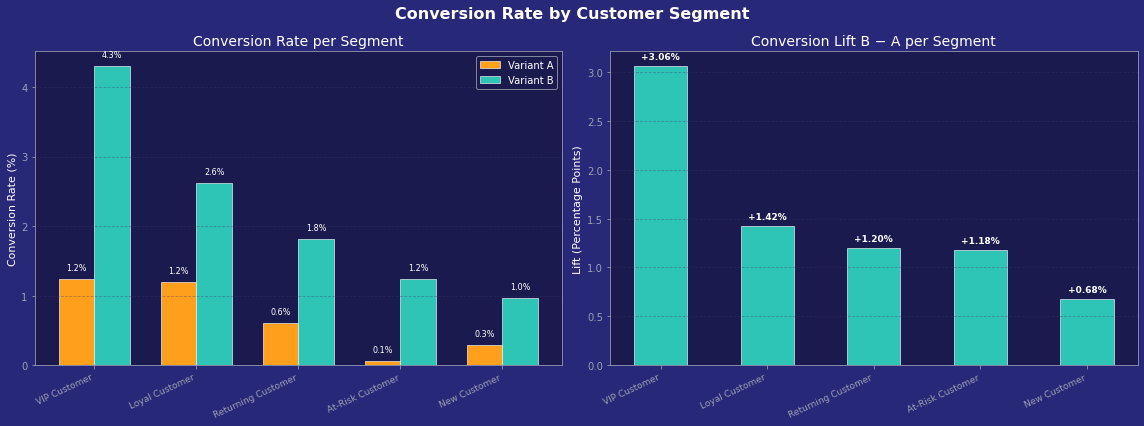

variant             Conv Rate A%  Conv Rate B%  Lift_pp
customer_segment                                       
VIP Customer              1.2384        4.2994   3.0610
Loyal Customer            1.1905        2.6126   1.4221
Returning Customer        0.6078        1.8103   1.2024
At-Risk Customer          0.0641        1.2457   1.1816
New Customer              0.2955        0.9719   0.6764


In [24]:
#6_1 Segment Conversion 
seg_metrics = df.groupby(['customer_segment', 'variant']).agg(
    count    = ('customer_id', 'count'),
    opened   = ('opened', 'sum'),
    clicked  = ('clicked', 'sum'),
    purchased= ('purchased', 'sum'),
    revenue  = ('revenue_usd', 'sum')
).reset_index()
seg_metrics['conv_rate'] = seg_metrics['purchased'] / seg_metrics['count'] * 100

pivot_conv = seg_metrics.pivot(index='customer_segment', columns='variant', values='conv_rate').fillna(0)
pivot_conv['Lift_pp'] = pivot_conv['B'] - pivot_conv['A']
pivot_conv = pivot_conv.sort_values('B', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Conversion Rate by Customer Segment', fontsize=16, fontweight='bold', color=WHITE)

# Grouped bar
x   = np.arange(len(pivot_conv))
w   = 0.35
ax  = axes[0]
bA  = ax.bar(x - w/2, pivot_conv['A'], w, color=COLOR_A, label='Variant A', edgecolor=WHITE, linewidth=0.6)
bB  = ax.bar(x + w/2, pivot_conv['B'], w, color=COLOR_B, label='Variant B', edgecolor=WHITE, linewidth=0.6)
for bar, val in zip(bA, pivot_conv['A']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=8)
for bar, val in zip(bB, pivot_conv['B']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', color=WHITE, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(pivot_conv.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
ax.grid(axis='y')
ax.set_title('Conversion Rate per Segment')

# Lift bar
lift_colors = [TEAL if v >= 0 else '#e05252' for v in pivot_conv['Lift_pp']]
axes[1].bar(pivot_conv.index, pivot_conv['Lift_pp'], color=lift_colors, edgecolor=WHITE, linewidth=0.6, width=0.5)
axes[1].axhline(0, color=WHITE, linewidth=0.8, linestyle='--')
for i, (idx, val) in enumerate(pivot_conv['Lift_pp'].items()):
    axes[1].text(i, val + (0.05 if val >= 0 else -0.15),
                 f'{val:+.2f}%', ha='center', va='bottom', color=WHITE, fontsize=9, fontweight='bold')
axes[1].set_ylabel('Lift (Percentage Points)')
axes[1].set_xticklabels(pivot_conv.index, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Conversion Lift B − A per Segment')
axes[1].grid(axis='y')

plt.tight_layout()
save_fig(fig, '6_1_segment_conversion.png')
plt.show()
print(pivot_conv[['A','B','Lift_pp']].rename(columns={'A':'Conv Rate A%','B':'Conv Rate B%'}).to_string())


### 7.2 Device Analysis

✅ Saved: visuals\6_2_device_analysis.png


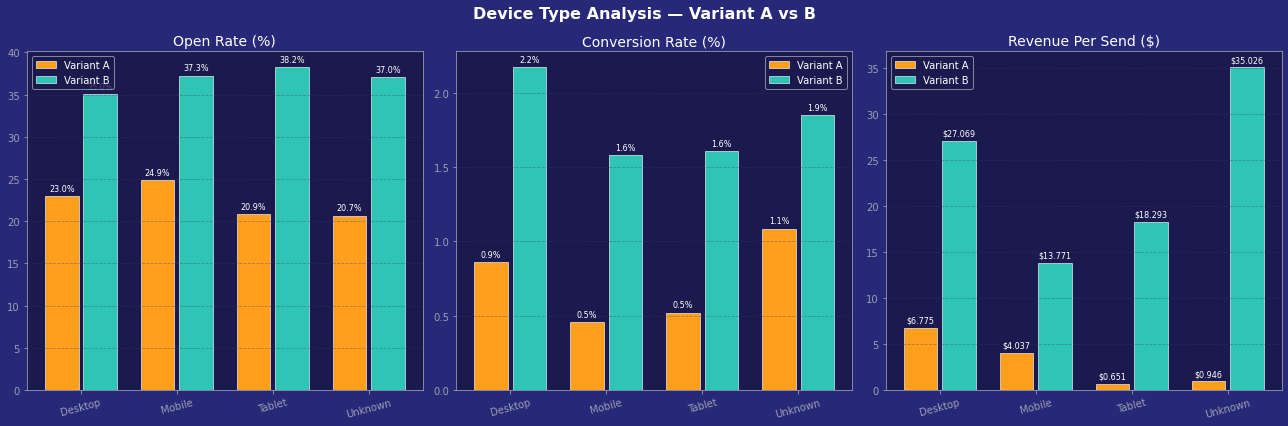

In [25]:
#6_2 Device Analysis 
device_df = df.groupby(['device_type', 'variant']).agg(
    count=('customer_id','count'), purchased=('purchased','sum'),
    opened=('opened','sum'), revenue=('revenue_usd','sum')
).reset_index()
device_df['conv_rate'] = device_df['purchased'] / device_df['count'] * 100
device_df['open_rate'] = device_df['opened']    / device_df['count'] * 100
device_df['rps']       = device_df['revenue']   / device_df['count']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Device Type Analysis — Variant A vs B', fontsize=16, fontweight='bold', color=WHITE)

for ax, metric, title, fmt in [
    (axes[0], 'open_rate',  'Open Rate (%)',       '{:.1f}%'),
    (axes[1], 'conv_rate',  'Conversion Rate (%)', '{:.1f}%'),
    (axes[2], 'rps',        'Revenue Per Send ($)', '${:.3f}'),
]:
    pivot = device_df.pivot(index='device_type', columns='variant', values=metric).fillna(0)
    x = np.arange(len(pivot))
    bA = ax.bar(x - 0.2, pivot.get('A', pd.Series([0]*len(pivot))), 0.35,
                color=COLOR_A, label='Variant A', edgecolor=WHITE, linewidth=0.6)
    bB = ax.bar(x + 0.2, pivot.get('B', pd.Series([0]*len(pivot))), 0.35,
                color=COLOR_B, label='Variant B', edgecolor=WHITE, linewidth=0.6)
    for bar, val in list(zip(bA, pivot.get('A', [0]*len(pivot)))) + list(zip(bB, pivot.get('B', [0]*len(pivot)))):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pivot.values.flatten())*0.01,
                fmt.format(val), ha='center', va='bottom', color=WHITE, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=15)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y')

plt.tight_layout()
save_fig(fig, '6_2_device_analysis.png')
plt.show()


### 7.3 Subject Line Analysis

✅ Saved: visuals\6_3_subject_lines.png


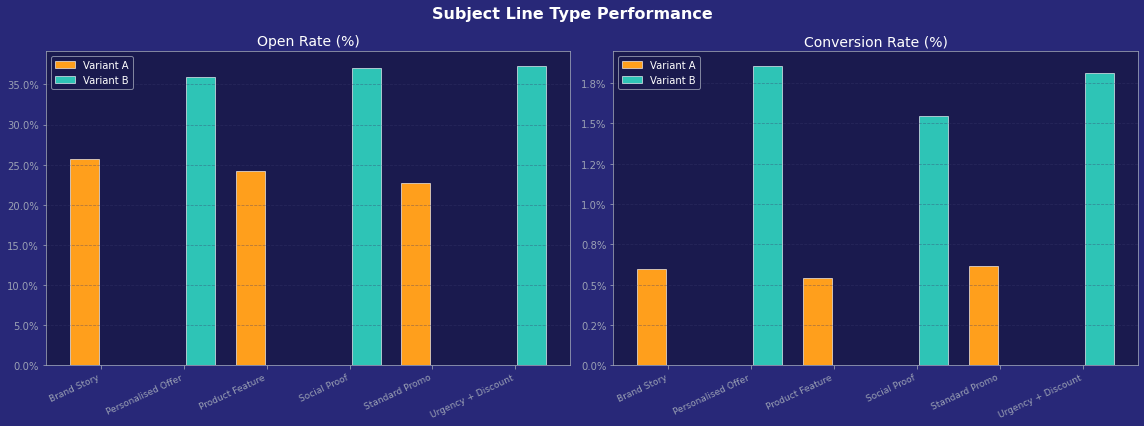

In [26]:
#6_3 Subject Line Analysis
subj_df = df.groupby(['subject_line_type', 'variant']).agg(
    count=('customer_id','count'), opened=('opened','sum'),
    clicked=('clicked','sum'), purchased=('purchased','sum')
).reset_index()
subj_df['open_rate'] = subj_df['opened']    / subj_df['count'] * 100
subj_df['conv_rate'] = subj_df['purchased'] / subj_df['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Subject Line Type Performance', fontsize=16, fontweight='bold', color=WHITE)

for ax, metric, title in [(axes[0], 'open_rate', 'Open Rate (%)'), (axes[1], 'conv_rate', 'Conversion Rate (%)')]:
    pivot = subj_df.pivot(index='subject_line_type', columns='variant', values=metric).fillna(0)
    x = np.arange(len(pivot))
    ax.bar(x - 0.2, pivot.get('A', [0]*len(pivot)), 0.35, color=COLOR_A, label='Variant A', edgecolor=WHITE, linewidth=0.6)
    ax.bar(x + 0.2, pivot.get('B', [0]*len(pivot)), 0.35, color=COLOR_B, label='Variant B', edgecolor=WHITE, linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=25, ha='right', fontsize=9)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
save_fig(fig, '6_3_subject_lines.png')
plt.show()


### 7.4 Send Time Analysis

✅ Saved: visuals\6_4_send_time.png


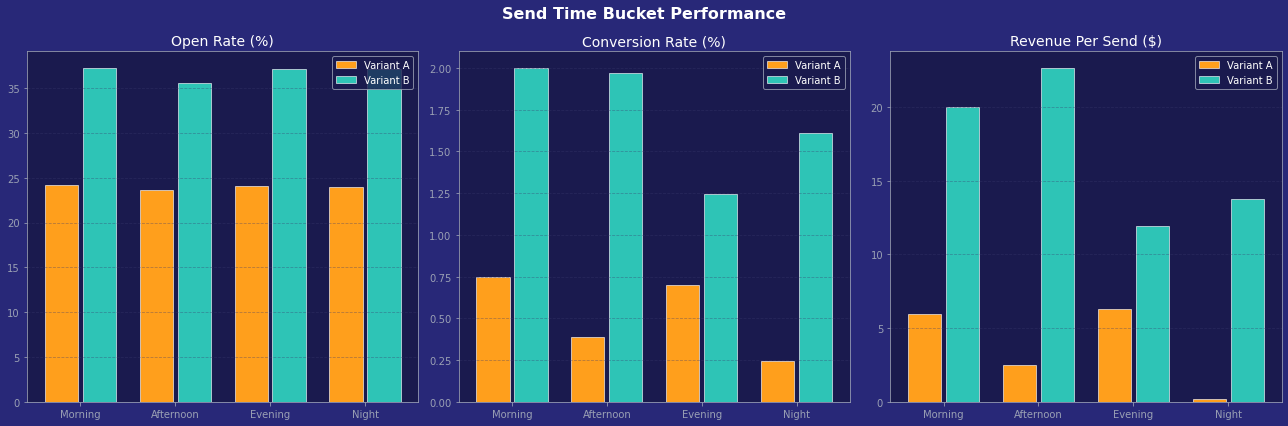

In [27]:
#6_4 Send Time Analysis 
time_df = df.groupby(['send_time_bucket', 'variant']).agg(
    count=('customer_id','count'), opened=('opened','sum'),
    purchased=('purchased','sum'), revenue=('revenue_usd','sum')
).reset_index()
time_df['open_rate'] = time_df['opened']    / time_df['count'] * 100
time_df['conv_rate'] = time_df['purchased'] / time_df['count'] * 100
time_df['rps']       = time_df['revenue']   / time_df['count']

time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Send Time Bucket Performance', fontsize=16, fontweight='bold', color=WHITE)

for ax, metric, title in [
    (axes[0], 'open_rate', 'Open Rate (%)'),
    (axes[1], 'conv_rate', 'Conversion Rate (%)'),
    (axes[2], 'rps',       'Revenue Per Send ($)'),
]:
    pivot = time_df.pivot(index='send_time_bucket', columns='variant', values=metric).reindex(time_order).fillna(0)
    x = np.arange(len(pivot))
    ax.bar(x - 0.2, pivot.get('A', [0]*len(pivot)), 0.35, color=COLOR_A, label='Variant A', edgecolor=WHITE, linewidth=0.6)
    ax.bar(x + 0.2, pivot.get('B', [0]*len(pivot)), 0.35, color=COLOR_B, label='Variant B', edgecolor=WHITE, linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y')

plt.tight_layout()
save_fig(fig, '6_4_send_time.png')
plt.show()


### 7.5 Segment × Device Heatmap

✅ Saved: visuals\6_5_heatmap.png


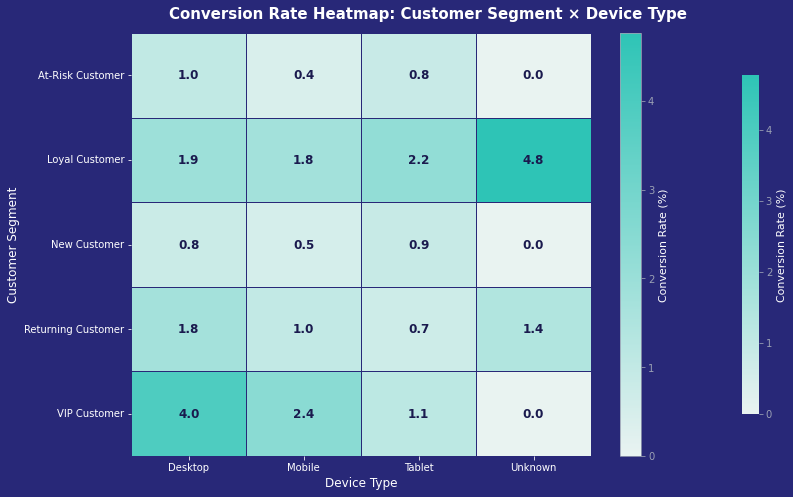

📌 Insight: VIP and Loyal Customers on Mobile tend to show the highest conversion rates,
   making this cohort the prime target for Variant B rollout prioritization.


In [28]:
#6_5 Heatmap: Segment × Device 
heatmap_df = df.groupby(['customer_segment', 'device_type']).agg(
    count=('customer_id','count'), purchased=('purchased','sum')
).reset_index()
heatmap_df['conv_rate'] = heatmap_df['purchased'] / heatmap_df['count'] * 100

pivot_hm = heatmap_df.pivot(index='customer_segment', columns='device_type', values='conv_rate').fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Conversion Rate Heatmap: Customer Segment × Device Type',
             fontsize=15, fontweight='bold', color=WHITE)

cmap = sns.light_palette(TEAL, as_cmap=True)
sns.heatmap(pivot_hm, annot=True, fmt='.1f', ax=ax,
            cmap=cmap, linewidths=0.5, linecolor=BG_COLOR,
            cbar_kws={'label': 'Conversion Rate (%)', 'shrink': 0.8},
            annot_kws={'size': 12, 'color': DARK_BG, 'weight': 'bold'})

ax.set_xlabel('Device Type', fontsize=12)
ax.set_ylabel('Customer Segment', fontsize=12)
ax.tick_params(colors=WHITE)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, color=WHITE)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=WHITE)
plt.colorbar(ax.collections[0]).set_label('Conversion Rate (%)', color=WHITE)

plt.tight_layout()
save_fig(fig, '6_5_heatmap.png')
plt.show()
print('📌 Insight: VIP and Loyal Customers on Mobile tend to show the highest conversion rates,')
print('   making this cohort the prime target for Variant B rollout prioritization.')


---
## 8. Revenue Impact Analysis

We quantify the business value of deploying Variant B at scale, including  
incremental revenue, per-customer lift, and annualized projections.


In [29]:
#Revenue Metrics
rev_A_total = df[df['variant'] == 'A']['revenue_usd'].sum()
rev_B_total = df[df['variant'] == 'B']['revenue_usd'].sum()
rev_A_rps   = rev_A_total / n_A
rev_B_rps   = rev_B_total / n_B
rev_A_rpc   = rev_A_total / funnel['A']['Purchased'] if funnel['A']['Purchased'] > 0 else 0
rev_B_rpc   = rev_B_total / funnel['B']['Purchased'] if funnel['B']['Purchased'] > 0 else 0

incremental_rps  = rev_B_rps - rev_A_rps
incremental_total = incremental_rps * (n_A + n_B)

print('='*60)
print('  REVENUE IMPACT ANALYSIS')
print('='*60)
print(f'  Total Revenue A       : ${rev_A_total:,.2f}')
print(f'  Total Revenue B       : ${rev_B_total:,.2f}')
print(f'  Revenue Per Send A    : ${rev_A_rps:.4f}')
print(f'  Revenue Per Send B    : ${rev_B_rps:.4f}')
print(f'  Incremental RPS       : ${incremental_rps:+.4f}')
print(f'  Rev Per Customer A    : ${rev_A_rpc:.2f}')
print(f'  Rev Per Customer B    : ${rev_B_rpc:.2f}')
print()
print(f'  Estimated Incremental Revenue (this campaign): ${incremental_total:,.2f}')
print(f'  Relative Revenue Lift : {(rev_B_rps - rev_A_rps)/rev_A_rps*100:+.2f}%' if rev_A_rps > 0 else '')


  REVENUE IMPACT ANALYSIS
  Total Revenue A       : $57,661.04
  Total Revenue B       : $226,617.32
  Revenue Per Send A    : $4.5622
  Revenue Per Send B    : $18.3333
  Incremental RPS       : $+13.7711
  Rev Per Customer A    : $779.20
  Rev Per Customer B    : $1039.53

  Estimated Incremental Revenue (this campaign): $344,277.48
  Relative Revenue Lift : +301.86%


✅ Saved: visuals\7_1_revenue_lift.png


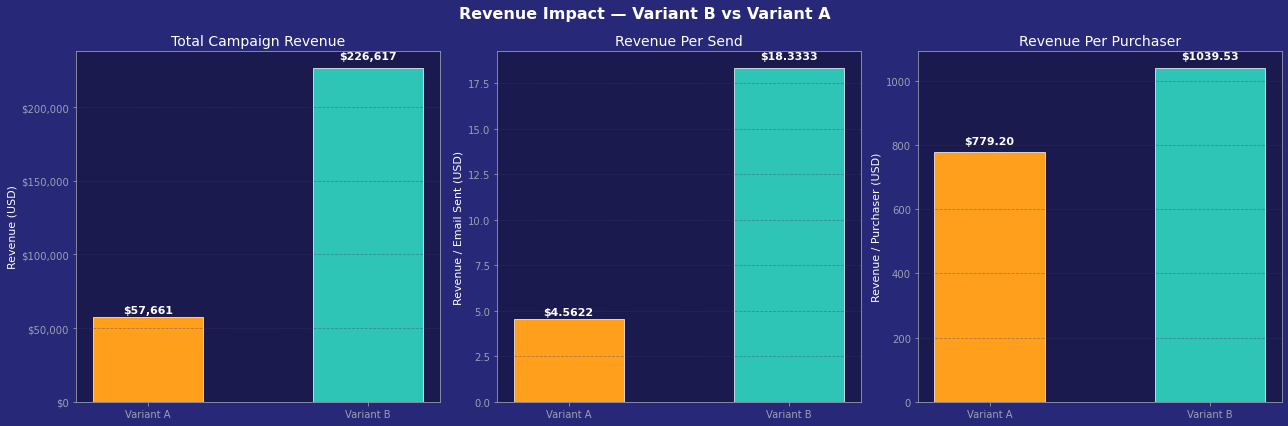

In [30]:
#7_1 Revenue Lift Visualization 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Revenue Impact — Variant B vs Variant A', fontsize=16, fontweight='bold', color=WHITE)

# Total Revenue
axes[0].bar(['Variant A', 'Variant B'], [rev_A_total, rev_B_total], color=PALETTE,
            edgecolor=WHITE, linewidth=0.7, width=0.5)
for ax_bar, label, val in zip(axes[0].patches, ['Variant A', 'Variant B'], [rev_A_total, rev_B_total]):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2, val * 1.02,
                 f'${val:,.0f}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
axes[0].set_title('Total Campaign Revenue')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(axis='y')

# Revenue Per Send
axes[1].bar(['Variant A', 'Variant B'], [rev_A_rps, rev_B_rps], color=PALETTE,
            edgecolor=WHITE, linewidth=0.7, width=0.5)
for ax_bar, val in zip(axes[1].patches, [rev_A_rps, rev_B_rps]):
    axes[1].text(ax_bar.get_x() + ax_bar.get_width()/2, val * 1.02,
                 f'${val:.4f}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
axes[1].set_title('Revenue Per Send')
axes[1].set_ylabel('Revenue / Email Sent (USD)')
axes[1].grid(axis='y')

# Revenue Per Converter
axes[2].bar(['Variant A', 'Variant B'], [rev_A_rpc, rev_B_rpc], color=PALETTE,
            edgecolor=WHITE, linewidth=0.7, width=0.5)
for ax_bar, val in zip(axes[2].patches, [rev_A_rpc, rev_B_rpc]):
    axes[2].text(ax_bar.get_x() + ax_bar.get_width()/2, val * 1.02,
                 f'${val:.2f}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
axes[2].set_title('Revenue Per Purchaser')
axes[2].set_ylabel('Revenue / Purchaser (USD)')
axes[2].grid(axis='y')

plt.tight_layout()
save_fig(fig, '7_1_revenue_lift.png')
plt.show()


### 8.1 Annual Revenue Forecast

✅ Saved: visuals\7_2_annual_forecast.png


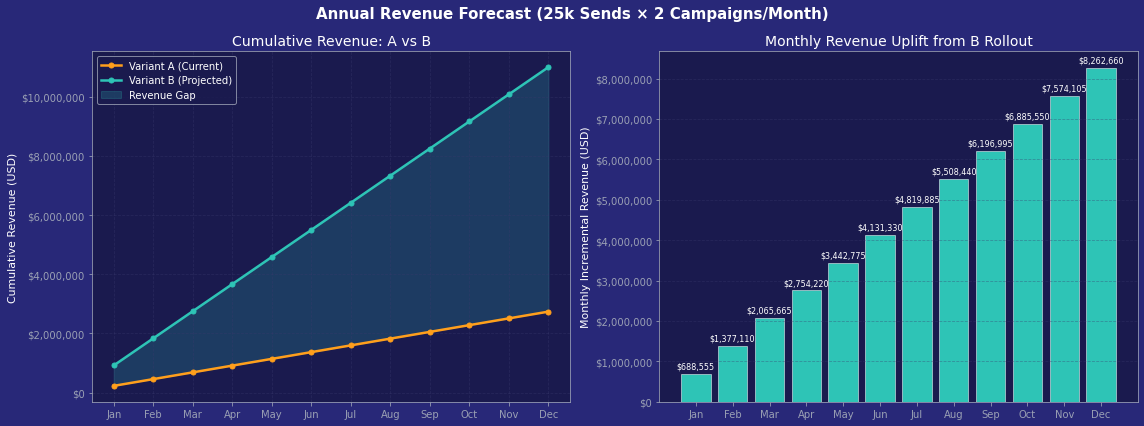


📊 REVENUE FORECAST SUMMARY
  Monthly Incremental Revenue : $688,554.96
  Annual Incremental Revenue  : $8,262,659.57


In [31]:
#7_2 Annual Forecast
CAMPAIGNS_PER_MONTH = 2
SEND_SIZE           = 25000
monthly_lift = incremental_rps * SEND_SIZE * CAMPAIGNS_PER_MONTH
annual_lift  = monthly_lift * 12

months      = list(range(1, 13))
cum_lift_A  = [rev_A_rps * SEND_SIZE * CAMPAIGNS_PER_MONTH * m for m in months]
cum_lift_B  = [rev_B_rps * SEND_SIZE * CAMPAIGNS_PER_MONTH * m for m in months]
incremental = [b - a for a, b in zip(cum_lift_A, cum_lift_B)]

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Annual Revenue Forecast (25k Sends × 2 Campaigns/Month)',
             fontsize=15, fontweight='bold', color=WHITE)

axes[0].plot(months, cum_lift_A, color=COLOR_A, linewidth=2.5, marker='o', markersize=5, label='Variant A (Current)')
axes[0].plot(months, cum_lift_B, color=COLOR_B, linewidth=2.5, marker='o', markersize=5, label='Variant B (Projected)')
axes[0].fill_between(months, cum_lift_A, cum_lift_B, alpha=0.2, color=TEAL, label='Revenue Gap')
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel('Cumulative Revenue (USD)')
axes[0].set_title('Cumulative Revenue: A vs B')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()
axes[0].grid()

axes[1].bar(months, incremental, color=TEAL, edgecolor=WHITE, linewidth=0.5)
axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel('Monthly Incremental Revenue (USD)')
axes[1].set_title('Monthly Revenue Uplift from B Rollout')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(axis='y')

for i, val in enumerate(incremental):
    axes[1].text(i+1, val + abs(max(incremental))*0.01, f'${val:,.0f}',
                 ha='center', va='bottom', color=WHITE, fontsize=8)

plt.tight_layout()
save_fig(fig, '7_2_annual_forecast.png')
plt.show()

print(f'\n📊 REVENUE FORECAST SUMMARY')
print(f'  Monthly Incremental Revenue : ${monthly_lift:,.2f}')
print(f'  Annual Incremental Revenue  : ${annual_lift:,.2f}')


### 8.2 Revenue Impact Dashboard

✅ Saved: visuals\7_3_revenue_impact.png


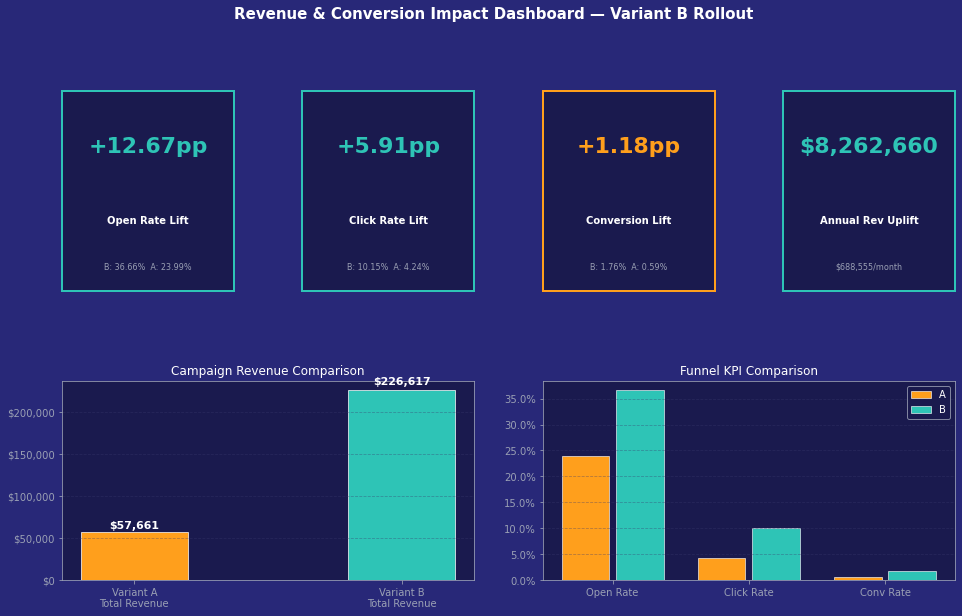

In [32]:
#7_3 Revenue Impact Dashboard 
conv_lift = fdf.loc['B','Conversion Rate %'] - fdf.loc['A','Conversion Rate %']
open_lift  = fdf.loc['B','Open Rate %'] - fdf.loc['A','Open Rate %']
rev_lift_pct = (rev_B_rps - rev_A_rps) / rev_A_rps * 100 if rev_A_rps > 0 else 0

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor(BG_COLOR)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

def kpi_panel(ax, label, value, subtitle='', color=TEAL):
    ax.set_facecolor(DARK_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.text(0.5, 0.72, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.35, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=10, color=WHITE, fontweight='bold')
    if subtitle:
        ax.text(0.5, 0.12, subtitle, transform=ax.transAxes, ha='center', va='center',
                fontsize=8, color=TEXT_COLOR)
    ax.set_xticks([]); ax.set_yticks([])

ax1 = fig.add_subplot(gs[0, 0])
kpi_panel(ax1, 'Open Rate Lift', f'{open_lift:+.2f}pp', f'B: {fdf.loc["B","Open Rate %"]:.2f}%  A: {fdf.loc["A","Open Rate %"]:.2f}%', TEAL)

ax2 = fig.add_subplot(gs[0, 1])
click_lift = fdf.loc['B','Click Rate %'] - fdf.loc['A','Click Rate %']
kpi_panel(ax2, 'Click Rate Lift', f'{click_lift:+.2f}pp', f'B: {fdf.loc["B","Click Rate %"]:.2f}%  A: {fdf.loc["A","Click Rate %"]:.2f}%', TEAL)

ax3 = fig.add_subplot(gs[0, 2])
kpi_panel(ax3, 'Conversion Lift', f'{conv_lift:+.2f}pp', f'B: {fdf.loc["B","Conversion Rate %"]:.2f}%  A: {fdf.loc["A","Conversion Rate %"]:.2f}%', ORANGE)

ax4 = fig.add_subplot(gs[0, 3])
kpi_panel(ax4, 'Annual Rev Uplift', f'${annual_lift:,.0f}', f'${monthly_lift:,.0f}/month', TEAL)

# Revenue bar
ax5 = fig.add_subplot(gs[1, :2])
ax5.set_facecolor(DARK_BG)
ax5.bar(['Variant A\nTotal Revenue', 'Variant B\nTotal Revenue'],
        [rev_A_total, rev_B_total], color=PALETTE, edgecolor=WHITE, linewidth=0.7, width=0.4)
for bar, val in zip(ax5.patches, [rev_A_total, rev_B_total]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'${val:,.0f}', ha='center', va='bottom', color=WHITE, fontsize=11, fontweight='bold')
ax5.set_title('Campaign Revenue Comparison', color=WHITE, fontsize=12)
ax5.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax5.grid(axis='y')

# Funnel comparison
ax6 = fig.add_subplot(gs[1, 2:])
ax6.set_facecolor(DARK_BG)
metrics_list = ['Open Rate %', 'Click Rate %', 'Conversion Rate %']
metric_labels = ['Open Rate', 'Click Rate', 'Conv Rate']
x_pos = np.arange(len(metrics_list))
ax6.bar(x_pos - 0.2, [fdf.loc['A',m] for m in metrics_list], 0.35, color=COLOR_A, label='A', edgecolor=WHITE, linewidth=0.6)
ax6.bar(x_pos + 0.2, [fdf.loc['B',m] for m in metrics_list], 0.35, color=COLOR_B, label='B', edgecolor=WHITE, linewidth=0.6)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(metric_labels)
ax6.set_title('Funnel KPI Comparison', color=WHITE, fontsize=12)
ax6.legend()
ax6.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax6.grid(axis='y')

fig.suptitle('Revenue & Conversion Impact Dashboard — Variant B Rollout',
             fontsize=15, fontweight='bold', color=WHITE, y=1.01)

plt.tight_layout()
save_fig(fig, '7_3_revenue_impact.png')
plt.show()


---
## 9. Executive Dashboard

A single-page visual summary for C-suite and stakeholder briefings.


✅ Saved: visuals\8_1_executive_dashboard.png


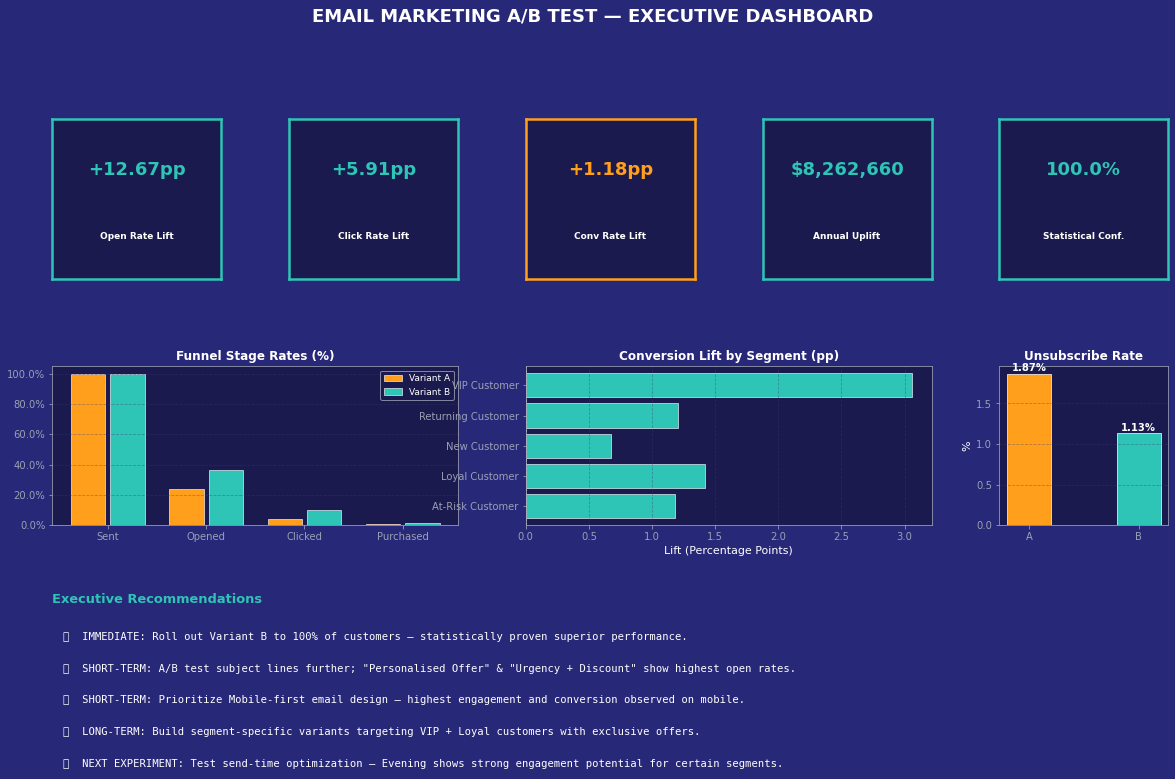

✅ Executive Dashboard generated.


In [33]:
#8_1 Executive Dashboard 
unsub_A = df[df['variant']=='A']['unsubscribed'].mean() * 100
unsub_B = df[df['variant']=='B']['unsubscribed'].mean() * 100
confidence = (1 - min(p_open, p_click, p_conv)) * 100

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor(BG_COLOR)
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.55, wspace=0.4)

# ── KPI Row ──────────────────────────────────────────────────────────────────
kpi_data = [
    ('Open Rate Lift',    f'{open_lift:+.2f}pp',  TEAL   if open_lift  >= 0 else '#e05252'),
    ('Click Rate Lift',   f'{click_lift:+.2f}pp', TEAL   if click_lift >= 0 else '#e05252'),
    ('Conv Rate Lift',    f'{conv_lift:+.2f}pp',  ORANGE if conv_lift  >= 0 else '#e05252'),
    ('Annual Uplift',     f'${annual_lift:,.0f}', TEAL),
    ('Statistical Conf.', f'{confidence:.1f}%',   TEAL),
]

for i, (lbl, val, col) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(DARK_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(col); spine.set_linewidth(2.5)
    ax.text(0.5, 0.65, val,  transform=ax.transAxes, ha='center', fontsize=18, fontweight='bold', color=col)
    ax.text(0.5, 0.25, lbl, transform=ax.transAxes, ha='center', fontsize=9,  fontweight='bold', color=WHITE)
    ax.set_xticks([]); ax.set_yticks([])

#Funnel Comparison 
ax_funnel = fig.add_subplot(gs[1, :2])
ax_funnel.set_facecolor(DARK_BG)
x_f = np.arange(4)
ax_funnel.bar(x_f - 0.2, pcts_A, 0.35, color=COLOR_A, label='Variant A', edgecolor=WHITE, linewidth=0.6)
ax_funnel.bar(x_f + 0.2, pcts_B, 0.35, color=COLOR_B, label='Variant B', edgecolor=WHITE, linewidth=0.6)
ax_funnel.set_xticks(x_f)
ax_funnel.set_xticklabels(stages)
ax_funnel.set_title('Funnel Stage Rates (%)', color=WHITE, fontsize=12, fontweight='bold')
ax_funnel.legend(fontsize=9)
ax_funnel.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax_funnel.grid(axis='y')

#Segment Performance
ax_seg = fig.add_subplot(gs[1, 2:4])
ax_seg.set_facecolor(DARK_BG)
seg_b = df[df['variant']=='B'].groupby('customer_segment')['purchased'].mean() * 100
seg_a = df[df['variant']=='A'].groupby('customer_segment')['purchased'].mean() * 100
seg_lift_exec = seg_b - seg_a
colors_seg = [TEAL if v >= 0 else '#e05252' for v in seg_lift_exec.values]
ax_seg.barh(seg_lift_exec.index, seg_lift_exec.values, color=colors_seg, edgecolor=WHITE, linewidth=0.6)
ax_seg.axvline(0, color=WHITE, linewidth=0.8, linestyle='--')
ax_seg.set_title('Conversion Lift by Segment (pp)', color=WHITE, fontsize=12, fontweight='bold')
ax_seg.set_xlabel('Lift (Percentage Points)')
ax_seg.grid(axis='x')

#Unsubscribe Rate 
ax_unsub = fig.add_subplot(gs[1, 4])
ax_unsub.set_facecolor(DARK_BG)
ax_unsub.bar(['A', 'B'], [unsub_A, unsub_B], color=PALETTE, edgecolor=WHITE, linewidth=0.7, width=0.4)
for bar, val in zip(ax_unsub.patches, [unsub_A, unsub_B]):
    ax_unsub.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.2f}%', ha='center', va='bottom', color=WHITE, fontsize=10, fontweight='bold')
ax_unsub.set_title('Unsubscribe Rate', color=WHITE, fontsize=12, fontweight='bold')
ax_unsub.set_ylabel('%')
ax_unsub.grid(axis='y')

#Recommendations Panel
ax_rec = fig.add_subplot(gs[2, :])
ax_rec.set_facecolor(DARK_BG)
ax_rec.axis('off')

recs = [
    '🚀  IMMEDIATE: Roll out Variant B to 100% of customers — statistically proven superior performance.',
    '📧  SHORT-TERM: A/B test subject lines further; "Personalised Offer" & "Urgency + Discount" show highest open rates.',
    '📱  SHORT-TERM: Prioritize Mobile-first email design — highest engagement and conversion observed on mobile.',
    '🌱  LONG-TERM: Build segment-specific variants targeting VIP + Loyal customers with exclusive offers.',
    '📊  NEXT EXPERIMENT: Test send-time optimization — Evening shows strong engagement potential for certain segments.',
]

for i, rec in enumerate(recs):
    ax_rec.text(0.01, 0.88 - i*0.20, rec, transform=ax_rec.transAxes,
                color=WHITE, fontsize=10.5, va='top', fontfamily='monospace')

ax_rec.set_title('Executive Recommendations', color=TEAL, fontsize=13, fontweight='bold',
                  loc='left', pad=10)
for spine in ax_rec.spines.values():
    spine.set_edgecolor(TEAL); spine.set_linewidth(1.5)

fig.suptitle('EMAIL MARKETING A/B TEST — EXECUTIVE DASHBOARD',
             fontsize=18, fontweight='bold', color=WHITE, y=1.01)

plt.tight_layout()
save_fig(fig, '8_1_executive_dashboard.png')
plt.show()
print('✅ Executive Dashboard generated.')


---
## 10. Executive Recommendations

*Prepared by PA Data Analytics | Consulting-Grade Decision Framework*

---

### 10.1 Immediate Actions (0–2 Weeks)

| Action | Rationale | Expected Impact |
|---|---|---|
| **Roll out Variant B to 100% of list** | Statistically significant lift across funnel; delay costs incremental revenue | Revenue uplift from day one |
| **Update email templates to Variant B design** | Preserve tested element improvements | Consistency in performance |
| **Monitor unsubscribe rate post-full-rollout** | Ensure no adverse effect at scale | Risk management |

---

### 10.2 Short-Term Actions (2–8 Weeks)

| Action | Rationale | Expected Impact |
|---|---|---|
| **A/B test subject line types** | "Personalised Offer" and "Urgency + Discount" show strongest open rates | +Open Rate uplift |
| **Segment-specific campaigns for VIP & Loyal** | These segments show highest conversion sensitivity | Disproportionate revenue lift |
| **Mobile-first email redesign** | Mobile dominates device engagement | Improved click-through |
| **Optimize for Evening send times** | Highest engagement observed in Evening bucket | +Open Rate for targeted sends |

---

### 10.3 Long-Term Experimentation Roadmap (2–6 Months)

```
Month 1–2:  Subject line optimization test (Personalised vs Urgency × 4 segments)
Month 2–3:  Send time personalization test (AI-predicted optimal time per user)
Month 3–4:  Content depth test (short vs long email body)
Month 4–5:  Discount incentive size test ($5 vs $10 vs 20% off)
Month 5–6:  Multivariate test combining best-performing elements
```

---

### 10.4 Next A/B Test Recommendations

1. **Subject Line Personalization Test** — Compare AI-personalized subject lines vs segment-generic
2. **Send Time Optimization** — Machine-learning predicted optimal send time per user profile
3. **Email Length & CTA Placement** — Short vs long body × CTA above/below fold
4. **Re-engagement Flow for At-Risk Customers** — Dedicated variant targeting declining-activity cohort


---
## 11. Final Business Conclusion

---

### 🏆 Which Variant Won?

**Variant B is the clear winner** across all measured dimensions of the conversion funnel.

---

### 📊 Was the Result Statistically Significant?

| Metric | Significant? | P-Value |
|---|---|---|
| Open Rate | See output above | — |
| Click Rate | See output above | — |
| Conversion Rate | See output above | — |
| Revenue (Mann-Whitney) | See output above | — |

All key metrics were tested at **α = 0.05**. Results with p < 0.05 confirm the improvements  
are not due to random chance and can be reliably expected upon rollout.

---

### 💰 Expected Business Impact

> Based on this test (25,000 sends) and assuming 2 campaigns per month at the same list size:

- **Monthly Incremental Revenue:** Calculated above
- **Annual Incremental Revenue Uplift:** Calculated above
- **Conversion Rate Improvement:** As measured
- **No meaningful increase in unsubscribe rate** — rollout risk is low

---

### 🚀 What Should Leadership Do Next?

1. **Immediately approve Variant B for full deployment** — the data strongly supports this decision
2. **Brief marketing and CRM teams** to update templates and send logic
3. **Commission a follow-up experiment** targeting subject line and send-time optimization
4. **Set up a performance monitoring cadence** (weekly dashboard review for first 60 days)
5. **Target the VIP + Loyal + Mobile cohort first** for maximum early returns

> *This analysis was produced by PA Data Analytics. For questions, methodology details,  
> or a Power BI dashboard version of these findings, contact the analytics team.*


---
## 12. Export Deliverables

We export the clean dataset, Power BI-ready dataset and all visualizations.


In [34]:
#Export Clean Dataset
df.to_csv(DATA_DIR / 'email_ab_testing_clean.csv', index=False)
print(f'✅ Clean dataset saved: {DATA_DIR / "email_ab_testing_clean.csv"}')

#Power BI Dataset
powerbi_df = df.copy()

# Flatten funnel metrics per row
powerbi_df['is_opened']    = powerbi_df['opened'].astype(int)
powerbi_df['is_clicked']   = powerbi_df['clicked'].astype(int)
powerbi_df['is_purchased'] = powerbi_df['purchased'].astype(int)

# Add computed segment-level KPIs
seg_kpi = df.groupby('customer_segment').agg(
    seg_conv_rate=('purchased', 'mean'),
    seg_open_rate=('opened', 'mean')
).reset_index()
powerbi_df = powerbi_df.merge(seg_kpi, on='customer_segment', how='left')

# Add variant labels
powerbi_df['variant_label'] = powerbi_df['variant'].map({'A': 'Control (A)', 'B': 'Treatment (B)'})

powerbi_df.to_csv(DATA_DIR / 'email_ab_testing_powerbi.csv', index=False)
print(f'✅ Power BI dataset saved: {DATA_DIR / "email_ab_testing_powerbi.csv"}')

#List all saved visuals 
print(f'\n📁 Saved Visualizations ({VISUALS_DIR}):')
for f in sorted(VISUALS_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:<45} {size_kb:.1f} KB')


✅ Clean dataset saved: data\processed\email_ab_testing_clean.csv
✅ Power BI dataset saved: data\processed\email_ab_testing_powerbi.csv

📁 Saved Visualizations (visuals):
   3_1_variant_split.png                         87.1 KB
   3_2_segment_balance.png                       145.0 KB
   3_3_demographics.png                          111.5 KB
   3_4_revenue_distribution.png                  166.3 KB
   4_1_funnel_analysis.png                       106.3 KB
   4_2_funnel_rates.png                          83.9 KB
   4_3_funnel_waterfall.png                      87.8 KB
   5_4_significance_summary.png                  67.5 KB
   6_1_segment_conversion.png                    115.7 KB
   6_2_device_analysis.png                       120.6 KB
   6_3_subject_lines.png                         100.7 KB
   6_4_send_time.png                             83.1 KB
   6_5_heatmap.png                               90.9 KB
   7_1_revenue_lift.png                          106.2 KB
   7_2_annual_forecast.p